D:/lidar/train/038_ЕЛИЗАВЕТИНСКОЕ_FINAL/05_Елизаветинское_Or/Снимки с геопривязкой/Елизаветенское_орто_привязанное.tif
Кол-во каналов: 3
Размеры (Ш x В): 3563 x 2515
Тип данных: uint8
Система координат (CRS): EPSG:32637
<class 'rasterio.crs.CRS'>
Границы (bounds): BoundingBox(left=484404.0967819423, bottom=4986833.741005005, right=485104.62163750955, top=4987328.217572996)
   id                                           geometry
0   2  MULTIPOLYGON (((3546766.54 7311787.864, 354674...
1   1  MULTIPOLYGON (((3546072.71 7312769.162, 354608...


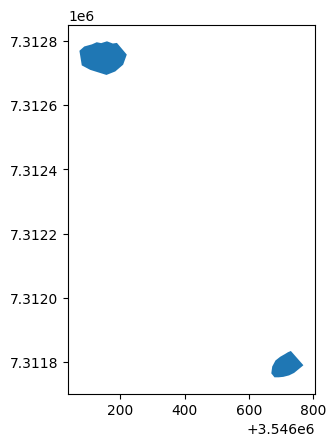

In [1]:
import rasterio
import geopandas as gpd 
file_path = 'D:/lidar/train/038_ЕЛИЗАВЕТИНСКОЕ_FINAL/05_Елизаветинское_Or/Снимки с геопривязкой/Елизаветенское_орто_привязанное.tif'
file_mask = 'D:/lidar/train/002_ДЕМИДОВКА_FINAL/06_Демидовка_разметка/Li/Демидовка_Li_городища.geojson'
with rasterio.open(file_path) as f:
    print(f.name)
    print(f"Кол-во каналов: {f.count}")
    print(f"Размеры (Ш x В): {f.width} x {f.height}")
    print(f"Тип данных: {f.dtypes[0]}")
    print(f"Система координат (CRS): {f.crs}")
    print(type(f.crs))
    print(f"Границы (bounds): {f.bounds}")

mask = gpd.read_file(file_mask)
mask.plot()
print(mask.head())

In [5]:
import torch
import albumentations as A
from my_dataset import GeoDataset
from torch.utils.data import DataLoader
from albumentations.pytorch import ToTensorV2
from typing import Dict

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Используется устройство: {DEVICE}")

LEARNING_RATE = 1e-4
BATCH_SIZE = 4
NUM_EPOCHS = 10
NUM_WORKERS = 2 
IMAGE_HEIGHT = 1024
IMAGE_WIDTH = 1024
PIN_MEMORY = True

INDEX_FILE = 'preprocessed_index.csv'
CHECKPOINT_PATH = "my_checkpoint.pth.tar"



train_transform = A.Compose([
    A.Resize(height=IMAGE_HEIGHT, width=IMAGE_WIDTH),
    A.Rotate(limit=35, p=0.7),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(height=IMAGE_HEIGHT, width=IMAGE_WIDTH),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

train_dataset = GeoDataset(
    index_file=INDEX_FILE,

    data_type_filter='Li',
    transforms=train_transform 
)
val_dataset = GeoDataset(
    index_file=INDEX_FILE,
    data_type_filter='Li', 
    transforms=val_transform 
)
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, shuffle=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, shuffle=False
)



Используется устройство: cuda


In [2]:
print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
image, mask = train_dataset[0]
print("Image shape:", image.shape)
print("Mask shape:", mask.shape)
print("Unique mask values:", mask.unique())

Train size: 1660
Val size: 1660
Image shape: torch.Size([3, 1024, 1024])
Mask shape: torch.Size([1024, 1024])
Unique mask values: tensor([0, 2])


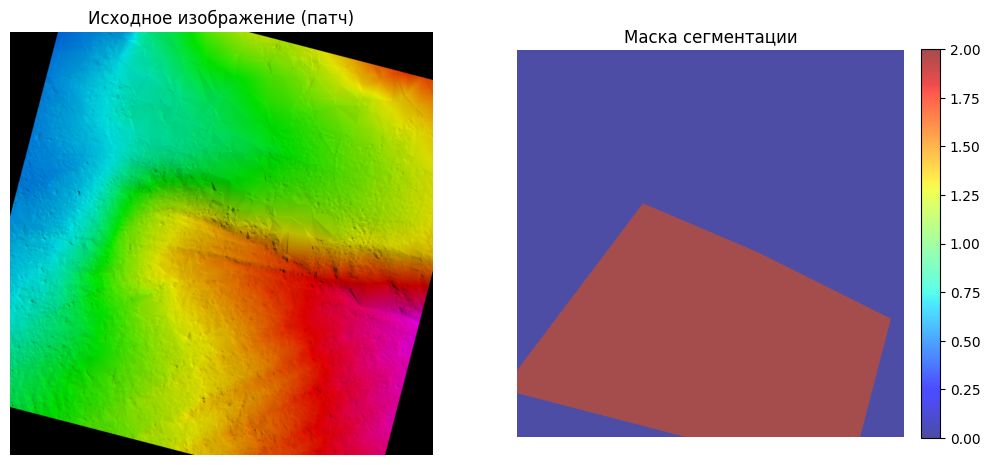

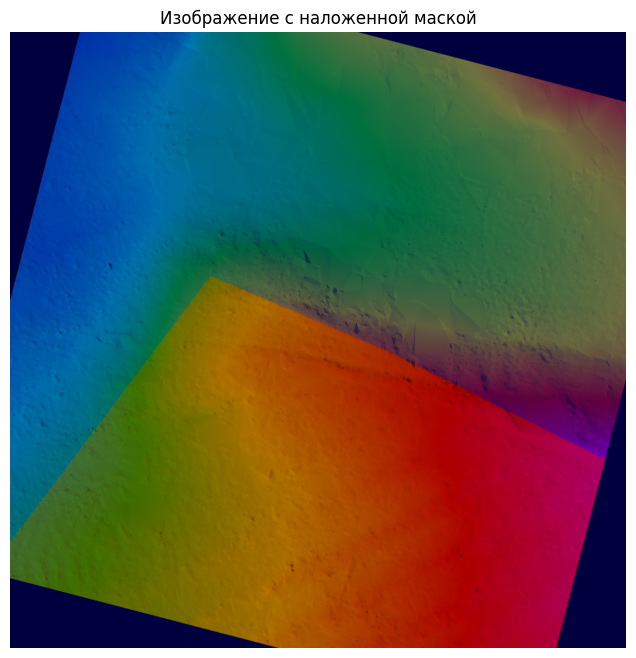

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch


image_tensor, mask_tensor = train_dataset[0] 
image_for_plot = image_tensor.permute(1, 2, 0).cpu().numpy()
mask_for_plot = mask_tensor.cpu().numpy()

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
image_for_plot = std * image_for_plot + mean
image_for_plot = np.clip(image_for_plot, 0, 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.imshow(image_for_plot)
ax1.set_title("Исходное изображение (патч)")
ax1.axis('off') 

im = ax2.imshow(mask_for_plot, cmap='jet', alpha=0.7)
ax2.set_title("Маска сегментации")
ax2.axis('off')

fig.colorbar(im, ax=ax2, orientation='vertical', fraction=0.046, pad=0.04)

plt.show()
plt.figure(figsize=(8, 8))
plt.imshow(image_for_plot)
plt.imshow(mask_for_plot, cmap='jet', alpha=0.5)
plt.title("Изображение с наложенной маской")
plt.axis('off')
plt.show()

In [3]:
import segmentation_models_pytorch as smp
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm

NUM_CLASSES = 12
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=NUM_CLASSES,
).to(DEVICE)

model = model.cuda()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()



In [6]:
def train_one_epoch(dl, model, criterion, optimizer):
    model.train()
    total_loss = 0
    pbar = tqdm(dl, desc="Train", unit="batch", leave=False)
    for images, masks in pbar:
        images = images.cuda()                                
        masks = masks.cuda()                                
        out = model(images)
        loss = criterion(out, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
    return total_loss / len(dl.dataset)

NUM_EPOCHS = 20
for epoch in range(NUM_EPOCHS):
    loss = train_one_epoch(train_loader, model, criterion, optimizer)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - loss: {loss:.4f}")

Epoch 1/20 - loss: 1.7094


KeyboardInterrupt: 